In [3]:
import galsim
from galsim import hsm
import matplotlib.pyplot as plt
import h5py
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

-0.015570240095257759 -0.01699555665254593 galsim.Shear(g1=-0.007786154344617252,g2=-0.008498907303922243)


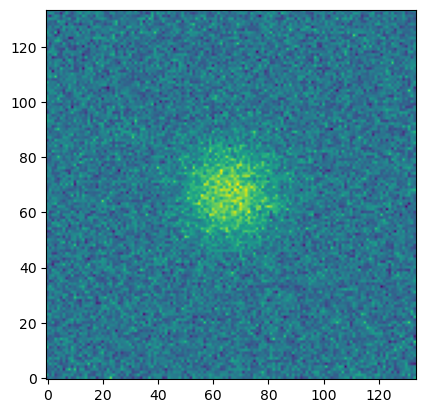

In [3]:
gal_flux = 1.e5    # total counts on the image
gal_sigma = 2.     # arcsec
psf_sigma = 1.     # arcsec
pixel_scale = 0.2  # arcsec / pixel
noise = 30.        # standard deviation of the counts in each pixel
gal = galsim.Gaussian(flux=gal_flux, sigma=gal_sigma)


psf = galsim.Gaussian(flux=1., sigma=psf_sigma) # PSF flux should always = 1
final = galsim.Convolve([gal, psf])
image = final.drawImage(scale=pixel_scale)
image.addNoise(galsim.GaussianNoise(sigma=noise))


results = image.FindAdaptiveMom()
plt.imshow(image.array,origin='lower')
print(results.observed_e1,results.observed_e2,results.observed_shape)

0.0002661705657374114 -0.00010281993309035897 galsim.Shear(g1=0.00013308528557761377,g2=-5.14099675916128e-05)


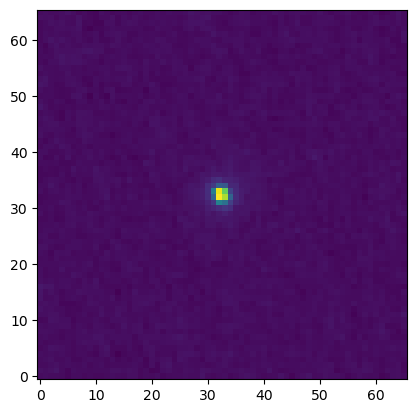

In [18]:
with h5py.File('../Dropbox/superNISP/data/Nircam_train.hdf5', 'r', swmr=True) as lr_hdf5:
    lr_image = lr_hdf5["train_img"][np.random.randint(1000), ...]

real_image = galsim.ImageF(66,66)
real_image.array = lr_image[0,:,:]
plt.imshow(real_image.array,origin='lower')
results = real_image.FindAdaptiveMom()
print(results.observed_e1,results.observed_e2,results.observed_shape)